In [9]:
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch

### Loading the dataset

In [11]:
path = Path(r".\News_Category_Dataset_v3.json")
df = pd.read_json(path, lines=True)

FileNotFoundError: File News_Category_Dataset_v3.json does not exist

### Let's take a look at data

In [ ]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
df.shape

(209527, 6)

### We have 6 columns and 200k+ rows.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


### There are no missing values which is good.

In [ ]:
print(f"Number of different categories: {df.category.nunique()}")
df.category.unique()

Number of different categories: 42


KeyboardInterrupt: 

### There are total 42 categories of news.

<Axes: xlabel='normalized count', ylabel='category'>

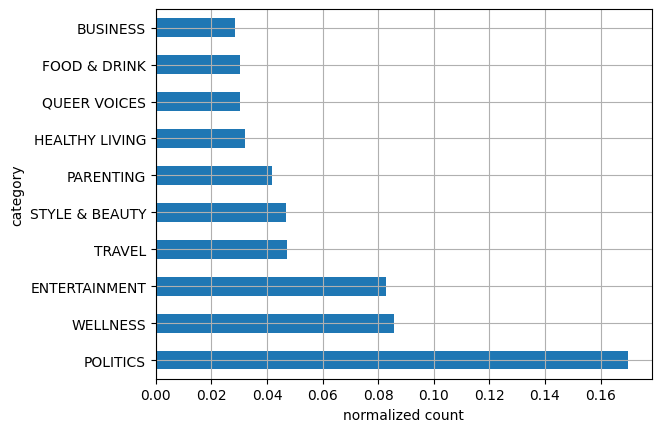

In [ ]:
df.category.value_counts(normalize=True).head(10).plot(kind='barh', grid=True, xlabel='normalized count')


### Many categories are similar to each other so I'm merging them here.

In [ ]:
merge_map = {
    'THE WORLDPOST': 'WORLD NEWS',
    'WORLDPOST' : 'WORLD NEWS',
    'ARTS & CULTURE': 'ARTS',
    'CULTURE & ARTS': 'ARTS',
    'STYLE': 'STYLE & BEAUTY',
    'PARENTING': 'PARENTS',
}

df['category'] = df['category'].replace(merge_map)

In [ ]:
df.category.nunique()

36

### Now we have 36 different categories

### For the simplicity of the model, I'll just combine all the text and make it the independent variable and the categories label as dependent variable

In [ ]:
df['text'] = df['headline'] + ". " + df['short_description']
df.head()

,link,headline,category,short_description,authors,date,text
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li..."
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTS,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...


In [13]:
clean_df = pd.read_csv(r'C:\SHASWAT\Projects\News-Classifier\data\processed\clean_df.csv')

### We need to change the category label from strings to number

In [14]:
# Encodeing the label strings to numeric values
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(clean_df['category']) 
class_names = label_encoder.classes_.tolist()  
clean_df['encoded_label'] = label_encoder.transform(clean_df['category'])

### Creating Training, Validation, and test Data

In [15]:
from sklearn.model_selection import train_test_split

# Creating test set
X, X_test, y, y_test = train_test_split(clean_df['text'], clean_df['encoded_label'], test_size=0.2, stratify=clean_df['category'], random_state=9)

# Creating train and validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

In [16]:
print(y_train.nunique())
print(y_val.nunique())
print(y_test.nunique())
print(y.nunique())

42
42
42
42


### All sets have all the labels included in them

# Building Model

### Making a tokenizer

In [17]:
from transformers import AutoTokenizer

bert = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(bert)
tokenizer.save_pretrained("../artifacts/tokenizer")

('../artifacts/tokenizer\\tokenizer_config.json',
 '../artifacts/tokenizer\\tokenizer.json')

### Creating Dataset and Dataloaders of our data

In [18]:
from torch.utils.data import Dataset, DataLoader
import torch

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Tokenization happens here
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

### Defining some parameters

In [19]:
# model parameters
max_len = 128
batch_size = 32
num_labels = len(label_encoder.classes_)
lr = 2e-5
num_workers = 0 # not used till now

In [20]:

train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=max_len)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=max_len)
test_dataset = NewsDataset(texts=X_test, labels=y_test, tokenizer=tokenizer, max_len=max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)

### Making the actual NLP model

### Here we are using a pretrained BERT model, and we will fine tune it.

In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    bert,
    num_labels=num_labels
)

# Moving the model on the gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Creating the class weights to balance the rare classes

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.arange(num_labels)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

In [24]:
type(y_train)

pandas.core.series.Series

### Defining the function to train our model

In [23]:
from torch.optim import AdamW
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup
from torch.nn import CrossEntropyLoss
import torch

optimizer = AdamW(model.parameters(), lr=lr)
num_epochs = 3 
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


# Initialize the mixed precision scaler (Updated API)
scaler = torch.amp.GradScaler('cuda')

def train_epoch(model, dataloader, optimizer, device, class_weights=None):
    model.train()
    total_loss = 0
    loss_fn = CrossEntropyLoss(weight=class_weights)
    
    accumulation_steps = 2 
    optimizer.zero_grad()
    
    for i, batch in enumerate(tqdm(dataloader)):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # 1. Run the forward pass in mixed precision (Updated API)
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            loss = loss_fn(outputs.logits, labels)
            # Scale the loss to account for gradient accumulation
            loss = loss / accumulation_steps 
        
        # 2. Scale gradients and run backward pass
        scaler.scale(loss).backward()
        
        # 3. Step the optimizer only after 'accumulation_steps' batches
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            
            scheduler.step()
            optimizer.zero_grad()
            
        # Re-multiply by accumulation_steps to keep your loss logging accurate
        total_loss += loss.item() * accumulation_steps
    
    return total_loss / len(dataloader)

### Defining a function to evaluate our model

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []
    total_loss = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, predictions)
    return avg_loss, accuracy

### Defining a function to give the final reprt of the model on the test set

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import torch

def test_model(model, dataloader, device):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)

    print(f"Test Accuracy: {accuracy:.4f}")

    print("\nClassification Report:\n")

    print(classification_report(true_labels, predictions, target_names=class_names, zero_division=0))

# Training Process

In [ ]:
best_val_loss = float('inf')  
patience = 2                  
epochs_without_improvement = 0
best_model_path = Path("./artifacts/models/model_v1")

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device, class_weights)
    val_loss, accuracy = evaluate(model, val_loader, device)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Accuracy: {accuracy:.4f}")

    # Is this the best model so far?
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        model.save_pretrained(best_model_path)   # save best weights
        tokenizer.save_pretrained(best_model_path)
        print(f"  → Best model saved (val_loss: {best_val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  → No improvement ({epochs_without_improvement}/{patience})")
        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

# Load best weights back for evaluation
model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
model.to(device)

100%|██████████| 4191/4191 [13:12<00:00,  5.29it/s]


Epoch 1: Train Loss=2.1771, Val Loss=1.3496, Accuracy: 0.6180, F1: 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Best model saved (val_loss: 1.3496)


100%|██████████| 4191/4191 [12:52<00:00,  5.42it/s]


...

Epoch 3: Train Loss=0.8475, Val Loss=1.1368, Accuracy: 0.6711, F1: 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → Best model saved (val_loss: 1.1368)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Results on the test set

In [ ]:
test_model(model, test_loader, device)

Test Accuracy: 0.6704

Classification Report:

                precision    recall  f1-score   support

          ARTS       0.57      0.66      0.61       784
  BLACK VOICES       0.47      0.61      0.53       917
      BUSINESS       0.54      0.56      0.55      1198
       COLLEGE       0.39      0.63      0.48       229
        COMEDY       0.52      0.61      0.56      1080
         CRIME       0.59      0.64      0.62       712
       DIVORCE       0.76      0.87      0.81       685
     EDUCATION       0.27      0.67      0.39       203
 ENTERTAINMENT       0.81      0.66      0.73      3473
   ENVIRONMENT       0.49      0.52      0.51       289
         FIFTY       0.32      0.56      0.41       280
  FOOD & DRINK       0.78      0.69      0.73      1268
     GOOD NEWS       0.38      0.49      0.43       280
         GREEN       0.38      0.57      0.46       524
HEALTHY LIVING       0.45      0.48      0.47      1339
 HOME & LIVING       0.80      0.87      0.83       864


# Using model to do actual predictions

In [ ]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    pred = torch.argmax(outputs.logits, dim=1).item()
    return label_encoder.inverse_transform([pred])[0]

predict("NASA launches new telescope to explore deep space")
# → 'SCIENCE'

'SCIENCE'

In [ ]:
predict("Hungry children, canceled benefits: Arizona's food stamp cuts are a warning for America Under Trump's “big, beautiful bill, families are going hungry as applicants fight to prove eligibility.")


'IMPACT'

In [ ]:
predict(""" Beijing/Washington DC — 

US President Donald Trump’s high-stakes visit to China this week is a historic opportunity for the world’s two largest economies to reframe their trade relationship — and the tone of their rivalry.

But to get there, he and Chinese leader Xi Jinping must navigate tricky frictions ranging from tech, trade, critical minerals and Taiwan in two days of meetings that are now also deeply overshadowed by the US war with Iran. """)

'WORLD NEWS'

# Saving model to disk

In [ ]:
# Saving 
import pickle

model.save_pretrained(best_model_path)
tokenizer.save_pretrained(best_model_path)

with open(f"{best_model_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Loading 
import pickle
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
tokenizer = AutoTokenizer.from_pretrained(best_model_path)

with open(f"{best_model_path}/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# Fine Tuning

### Since in the original data, the classes were highly imbalanced. I'll fine tune my model on the balanced data set by selecting 1000 samples of each label. 

In [ ]:
n_samples = 1000
balanced_df = clean_df.groupby('category').sample(n = n_samples, random_state=9).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

# Creating training and validation set
X_train, X_val, y_train, y_val = train_test_split(balanced_df['text'], balanced_df['encoded_label'], test_size=0.2, stratify=balanced_df['category'], random_state=9)


In [ ]:

train_dataset = NewsDataset(X_train, y_train, tokenizer, max_len=max_len)
val_dataset = NewsDataset(X_val, y_val, tokenizer, max_len=max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers)


In [ ]:
# Fine tuning
optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 1 # I'll do just one epoch for fine tuning
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


# Initialize the mixed precision scaler (Updated API)
scaler = torch.amp.GradScaler('cuda')


for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss, accuracy = evaluate(model, val_loader, device)
    print(f"Epoch {epoch+4}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Accuracy: {accuracy:.4f}")

100%|██████████| 900/900 [03:50<00:00,  3.91it/s]


Epoch 4: Train Loss=0.5948, Val Loss=0.7006, Accuracy: 0.7987, f1_score: 0.0


In [ ]:
test_model(model, test_loader, device)

Test Accuracy: 0.6568

Classification Report:

                precision    recall  f1-score   support

          ARTS       0.49      0.69      0.57       784
  BLACK VOICES       0.47      0.61      0.53       917
      BUSINESS       0.55      0.53      0.54      1198
       COLLEGE       0.38      0.74      0.51       229
        COMEDY       0.52      0.61      0.56      1080
         CRIME       0.54      0.70      0.61       712
       DIVORCE       0.78      0.84      0.81       685
     EDUCATION       0.33      0.82      0.47       203
 ENTERTAINMENT       0.84      0.61      0.70      3473
   ENVIRONMENT       0.41      0.58      0.48       289
         FIFTY       0.24      0.64      0.35       280
  FOOD & DRINK       0.75      0.73      0.74      1268
     GOOD NEWS       0.37      0.49      0.42       280
         GREEN       0.37      0.53      0.44       524
HEALTHY LIVING       0.45      0.43      0.44      1339
 HOME & LIVING       0.80      0.86      0.83       864


### Saving the fine tuned model

In [ ]:
# Saving 
import pickle

fine_tuned_model_path = 'fine_tuned_model'
model.save_pretrained(fine_tuned_model_path)
tokenizer.save_pretrained(fine_tuned_model_path)

with open(f"{fine_tuned_model_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
class_names_path = Path("./artifacts/encoder/class_names.pkl")
class_names_path.exists()


True